In [48]:
import pandas as pd
import numpy as np

# Liste des fichiers CSV
files = ['data/TotalEnergiesSE Stock Price History.csv',
        'data/Apple Stock Price History.csv', 
        'data/Louis Vuitton Stock Price History.csv', 
        'data/BNP Paribas Stock Price History.csv', 
        'data/Vinci Stock Price History.csv', 
        'data/FR_OAT.csv',
        'data/Nasdaq 100 Historical Data.csv',
        'data/CAC 40 Historical Data.csv']
titres = ['TotalEnergies', 'Apple', 'LVMH', 'BNP', 'Vinci', 'OAT','Nasdaq','CAC 40']

# Initialisation d'une liste pour stocker les DataFrames
full_data = []

# Chargement de chaque fichier
for f, titre in zip(files, titres):
    mydata = pd.read_csv(f, parse_dates=['Date']) 
    mydata = mydata[['Date', 'Price']].rename(columns={'Price': titre})
    full_data.append(mydata)


In [49]:
# Fusionner tous les fichiers sur la colonne Date en conservant toutes les dates
from functools import reduce
titres_df = reduce(lambda left, right: pd.merge(left, right, on='Date', how='outer'), full_data)

# Trier par date
titres_df = titres_df.sort_values('Date').reset_index(drop=True)
titres_df.head(10)

,Date,TotalEnergies,Apple,LVMH,BNP,Vinci,OAT,Nasdaq,CAC 40
0,2021-11-23,42.88,161.41,718.1,58.89,90.58,100.33,"16,306.72","7,044.62"
1,2021-11-24,43.12,161.94,726.1,58.54,91.60,100.19,"16,367.81","7,042.23"
2,2021-11-25,43.09,NaN,734.7,58.73,91.77,100.36,NaN,"7,075.87"
3,2021-11-26,40.53,156.81,692.0,55.29,84.02,101.01,"16,025.58","6,739.73"
4,2021-11-29,41.20,160.24,697.2,55.38,84.16,100.79,"16,399.24","6,776.25"
5,2021-11-30,40.61,165.30,686.6,55.08,83.66,101.07,"16,135.92","6,721.16"
6,2021-12-01,41.94,164.77,697.5,56.59,86.32,101.05,"15,877.72","6,881.87"
7,2021-12-02,42.02,163.76,686.6,56.45,86.74,101.36,"15,990.76","6,795.75"
8,2021-12-03,42.34,161.84,685.0,56.17,85.32,101.46,"15,712.04","6,765.52"
9,2021-12-06,43.44,165.32,690.1,57.34,87.11,101.40,"15,846.16","6,865.78"


In [50]:
titres_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1038 non-null   datetime64[ns]
 1   TotalEnergies  1026 non-null   float64       
 2   Apple          1004 non-null   float64       
 3   LVMH           1026 non-null   float64       
 4   BNP            1026 non-null   float64       
 5   Vinci          1026 non-null   float64       
 6   OAT            1016 non-null   float64       
 7   Nasdaq         1004 non-null   object        
 8   CAC 40         1026 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 73.1+ KB


In [51]:
titres_df['Nasdaq'] = titres_df['Nasdaq'].str.replace(",", "").astype(float)
titres_df['CAC 40'] = titres_df['CAC 40'].str.replace(",", "").astype(float)
titres_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1038 non-null   datetime64[ns]
 1   TotalEnergies  1026 non-null   float64       
 2   Apple          1004 non-null   float64       
 3   LVMH           1026 non-null   float64       
 4   BNP            1026 non-null   float64       
 5   Vinci          1026 non-null   float64       
 6   OAT            1016 non-null   float64       
 7   Nasdaq         1004 non-null   float64       
 8   CAC 40         1026 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 73.1 KB


In [52]:
# Interpolation des Na avec la moyenne des valeurs précédente et suivante
titres_df.interpolate(method='linear', inplace=True)
titres_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1038 non-null   datetime64[ns]
 1   TotalEnergies  1038 non-null   float64       
 2   Apple          1038 non-null   float64       
 3   LVMH           1038 non-null   float64       
 4   BNP            1038 non-null   float64       
 5   Vinci          1038 non-null   float64       
 6   OAT            1038 non-null   float64       
 7   Nasdaq         1038 non-null   float64       
 8   CAC 40         1038 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 73.1 KB


In [53]:
titres_df.head(10)

,Date,TotalEnergies,Apple,LVMH,BNP,Vinci,OAT,Nasdaq,CAC 40
0,2021-11-23,42.88,161.410,718.1,58.89,90.58,100.33,16306.720,7044.62
1,2021-11-24,43.12,161.940,726.1,58.54,91.60,100.19,16367.810,7042.23
2,2021-11-25,43.09,159.375,734.7,58.73,91.77,100.36,16196.695,7075.87
3,2021-11-26,40.53,156.810,692.0,55.29,84.02,101.01,16025.580,6739.73
4,2021-11-29,41.20,160.240,697.2,55.38,84.16,100.79,16399.240,6776.25
5,2021-11-30,40.61,165.300,686.6,55.08,83.66,101.07,16135.920,6721.16
6,2021-12-01,41.94,164.770,697.5,56.59,86.32,101.05,15877.720,6881.87
7,2021-12-02,42.02,163.760,686.6,56.45,86.74,101.36,15990.760,6795.75
8,2021-12-03,42.34,161.840,685.0,56.17,85.32,101.46,15712.040,6765.52
9,2021-12-06,43.44,165.320,690.1,57.34,87.11,101.40,15846.160,6865.78


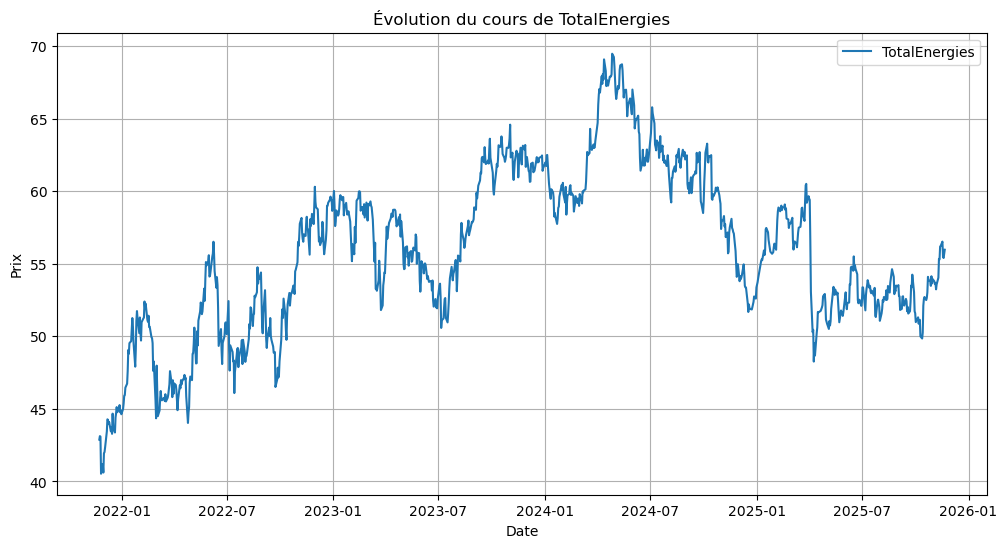

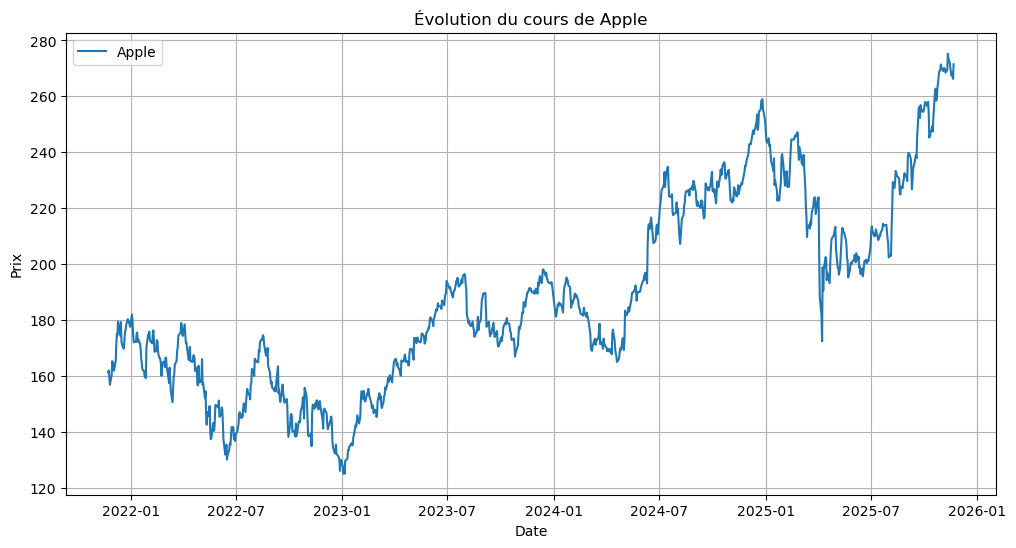

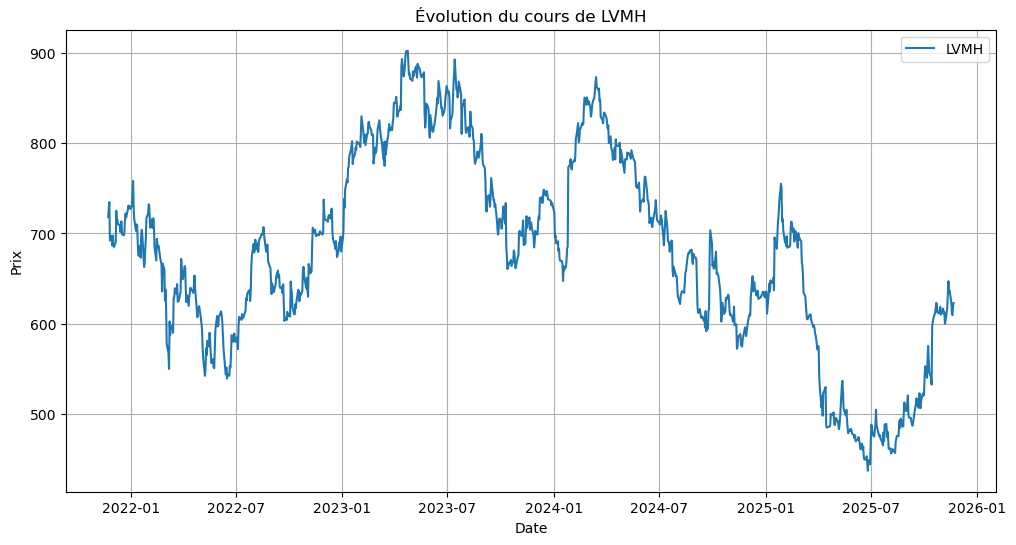

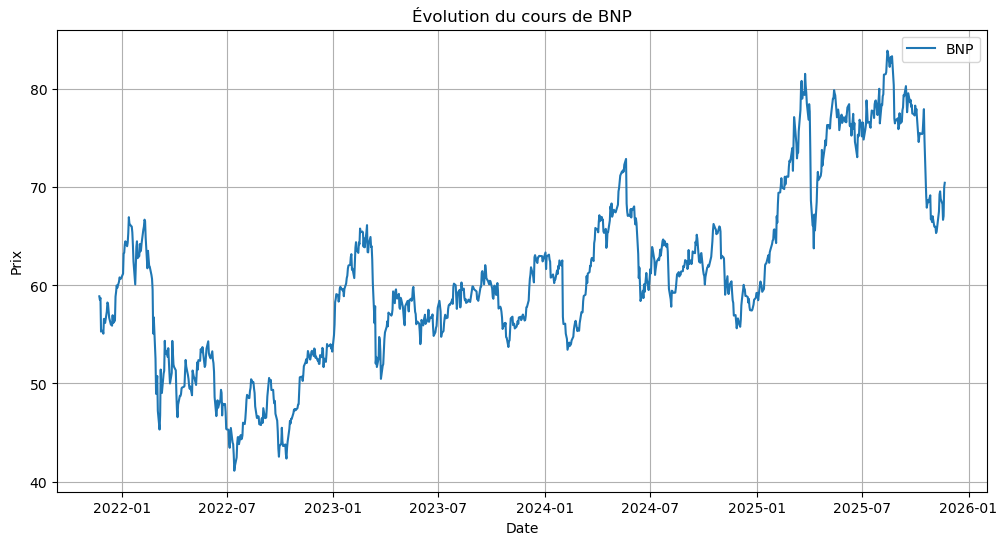

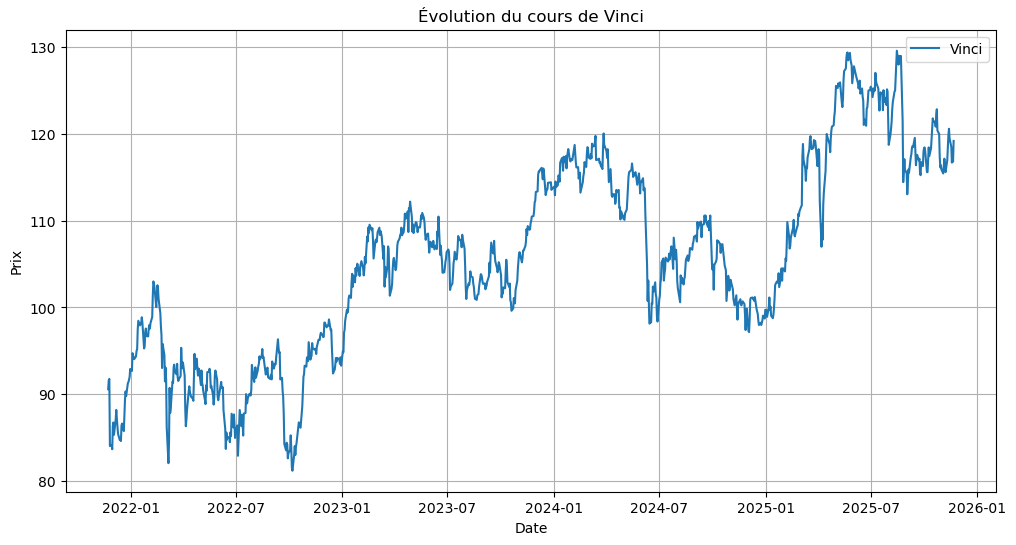

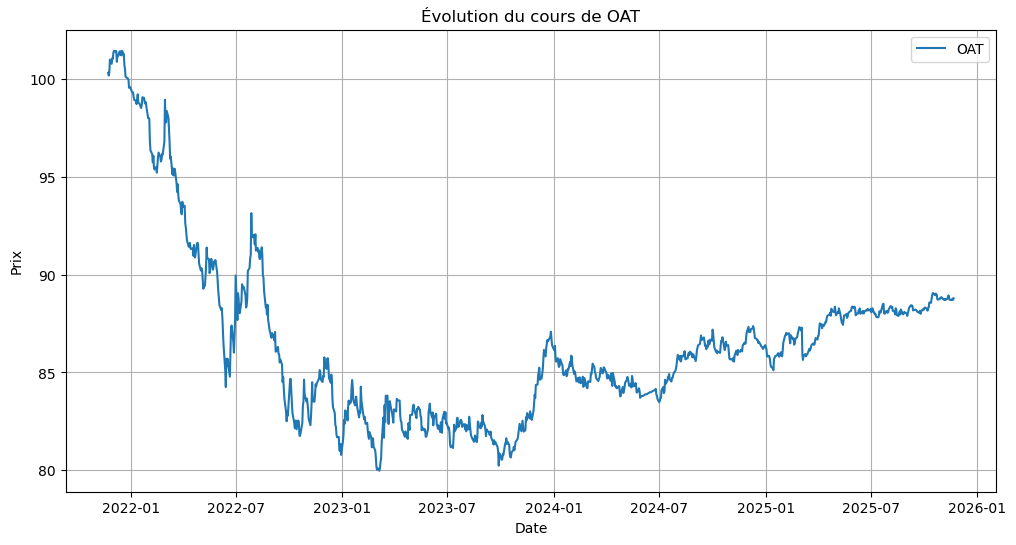

In [54]:
import matplotlib.pyplot as plt

# Sélection des colonnes des actifs du portefeuille à constituer
actifs = ['TotalEnergies', 'Apple', 'LVMH', 'BNP', 'Vinci', 'OAT']
actifs_df = titres_df[actifs]

for actif in actifs:
    plt.figure(figsize=(12, 6))  # Nouveau graphique pour chaque actif
    plt.plot(titres_df['Date'], actifs_df[actif], label=actif)
    plt.title(f"Évolution du cours de {actif}")
    plt.xlabel("Date")
    plt.ylabel("Prix")
    plt.legend()
    plt.grid(True)
    plt.show()


In [55]:
# Calcul des rendements logarithmiques
returns_df = np.log(titres_df[titres] / titres_df[titres].shift(1)).dropna()
returns_df.insert(0, 'Date', titres_df['Date'].reset_index(drop=True))
returns_df.head(10)

,Date,TotalEnergies,Apple,LVMH,BNP,Vinci,OAT,Nasdaq,CAC 40
1,2021-11-24,0.005581,0.003278,0.011079,-0.005961,0.011198,-0.001396,0.003739,-0.000339
2,2021-11-25,-0.000696,-0.015966,0.011775,0.003240,0.001854,0.001695,-0.010509,0.004766
3,2021-11-26,-0.061249,-0.016225,-0.059876,-0.060359,-0.088231,0.006456,-0.010621,-0.048671
4,2021-11-29,0.016396,0.021638,0.007486,0.001626,0.001665,-0.002180,0.023049,0.005404
5,2021-11-30,-0.014424,0.031089,-0.015320,-0.005432,-0.005959,0.002774,-0.016187,-0.008163
6,2021-12-01,0.032226,-0.003211,0.015751,0.027046,0.031300,-0.000198,-0.016131,0.023630
7,2021-12-02,0.001906,-0.006149,-0.015751,-0.002477,0.004854,0.003063,0.007094,-0.012593
8,2021-12-03,0.007587,-0.011794,-0.002333,-0.004972,-0.016506,0.000986,-0.017584,-0.004458
9,2021-12-06,0.025648,0.021275,0.007418,0.020616,0.020763,-0.000592,0.008500,0.014711
10,2021-12-07,0.019152,0.034833,0.049335,0.015917,0.012322,0.000394,0.029811,0.028659


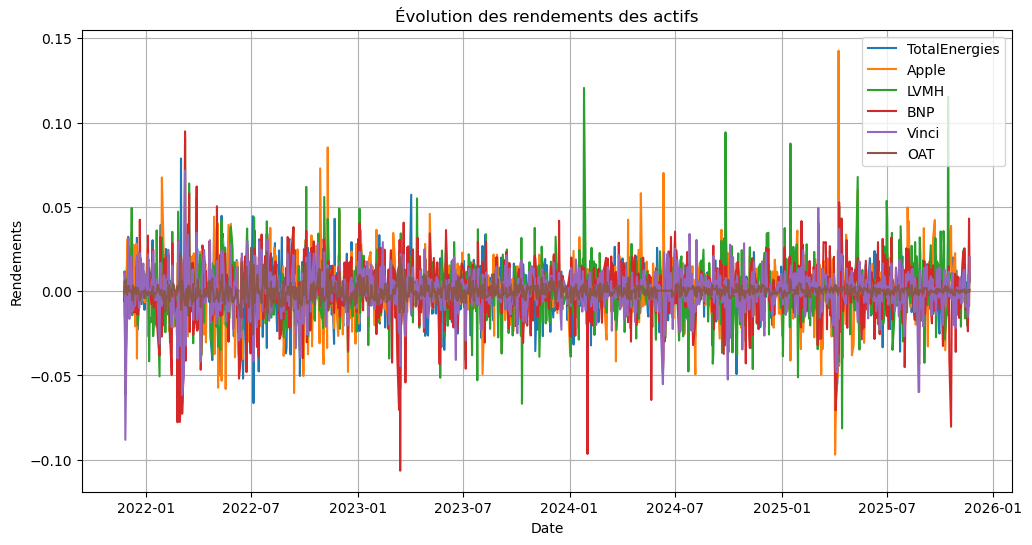

In [56]:
# Création du graphique
plt.figure(figsize=(12, 6))  # Taille du graphique
returns_df_actif = returns_df[actifs]
for actif_rdt in returns_df_actif:
    plt.plot(returns_df['Date'], returns_df_actif[actif_rdt], label=actif_rdt)

plt.title("Évolution des rendements des actifs")
plt.xlabel("Date")
plt.ylabel("Rendements")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
returns_df.set_index('Date', inplace=True)
monthly_returns = returns_df.resample('M').sum()
monthly_returns = monthly_returns.reset_index()
monthly_returns.head(5)

C:\Users\Visiteur.SEGK205-3181VB6\AppData\Local\Temp\ipykernel_11956\971818407.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = returns_df.resample('M').sum()


,Date,TotalEnergies,Apple,LVMH,BNP,Vinci,OAT,Nasdaq,CAC 40
0,2021-11-30,-0.054391,0.023814,-0.044857,-0.066885,-0.079472,0.007349,-0.010529,-0.047003
1,2021-12-31,0.094392,0.071603,0.057175,0.098310,0.104870,-0.014651,0.011348,0.062275
2,2022-01-31,0.118007,-0.015837,-0.006071,0.036038,0.039568,-0.016093,-0.089020,-0.021740
3,2022-02-28,-0.096725,-0.056856,-0.090768,-0.182131,-0.022388,-0.012423,-0.047475,-0.049852
4,2022-03-31,0.009605,0.055882,-0.016039,-0.011107,-0.016319,-0.032229,0.041323,0.000156


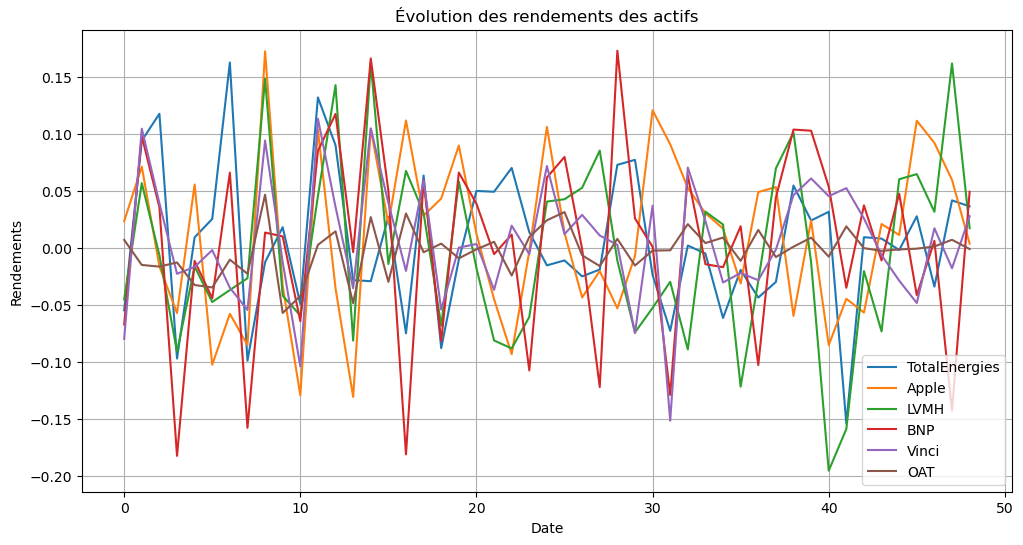

In [39]:
# Création du graphique
plt.figure(figsize=(12, 6))  # Taille du graphique
returns_df_actif = monthly_returns[actifs]
for actif_rdt in returns_df_actif:
    plt.plot(returns_df_actif.index, returns_df_actif[actif_rdt], label=actif_rdt)

plt.title("Évolution des rendements des actifs")
plt.xlabel("Date")
plt.ylabel("Rendements")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
trading_days = 252

# DataFrame pour stocker les résultats
actif_stats = pd.DataFrame(index=actifs, columns=["Mean_annualized (%)", "Vol_annualized (%)"])

for actif in actifs:
    daily_returns = returns_df[actif]

    # Moyenne annualisée des rendements log
    mean_ann = daily_returns.mean() * trading_days

    # Volatilité annualisée
    vol_ann = daily_returns.std() * np.sqrt(trading_days)
    actif_stats.loc[actif] = [
        f"{mean_ann*100:.4f}", 
        f"{vol_ann*100:.4f}"
    ]


# Affichage
print(actif_stats)


              Mean_annualized (%) Vol_annualized (%)
TotalEnergies              6.4740            24.3718
Apple                     12.6359            28.0354
LVMH                      -3.4522            30.0575
BNP                        4.3624            28.8213
Vinci                      6.6723            20.9647
OAT                       -2.9693             6.9121


In [ ]:
# Liste des actifs et leur indice de référence
actifs_indices = {
    'TotalEnergies': 'CAC 40',
    'LVMH': 'CAC 40',
    'BNP': 'CAC 40',
    'Vinci': 'CAC 40',
    'Apple': 'Nasdaq',
}

# DataFrame pour stocker alpha et beta
alpha_beta_df = pd.DataFrame(columns=['Alpha', 'Beta'])

for actif, indice in actifs_indices.items():
    R_actif = returns_df[actif]
    R_indice = returns_df[indice]

    # Calcul du beta
    beta = np.cov(R_actif, R_indice)[0, 1] / np.var(R_indice)
    
    # Calcul de l'alpha
    alpha = R_actif.mean() - beta * R_indice.mean()
    
    alpha_beta_df.loc[actif] = [round(alpha, 4), round(beta, 4)]

print(alpha_beta_df)


                Alpha    Beta
TotalEnergies  0.0002  0.7487
LVMH          -0.0003  1.3749
BNP            0.0000  1.2253
Vinci          0.0002  0.9159
Apple          0.0001  0.9286


In [76]:
daily_returns = returns_df[actifs]
mu = daily_returns.mean() * trading_days
mu

TotalEnergies    0.064740
Apple            0.126359
LVMH            -0.034522
BNP              0.043624
Vinci            0.066723
OAT             -0.029693
dtype: float64

In [77]:
cov = daily_returns.cov() * trading_days
cov

,TotalEnergies,Apple,LVMH,BNP,Vinci,OAT
TotalEnergies,0.059399,0.006487,0.021283,0.030241,0.018752,-0.003486
Apple,0.006487,0.078598,0.021413,0.011863,0.008718,0.001048
LVMH,0.021283,0.021413,0.090346,0.036572,0.027062,0.000145
BNP,0.030241,0.011863,0.036572,0.083067,0.038419,-0.002784
Vinci,0.018752,0.008718,0.027062,0.038419,0.043952,0.000067
OAT,-0.003486,0.001048,0.000145,-0.002784,0.000067,0.004778


In [79]:
# Construction du portefeuille optimal via Markowitz
from scipy.optimize import minimize

# Fonction objectif : maximiser le Sharpe ratio (rendement / volatilité)
def sharpe_ratio(weights, mu, cov, rf=0.0):
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return - (port_return - rf) / port_vol  # négatif pour minimiser

# Contraintes : somme des poids = 1, long only
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0,1) for _ in actifs)

# Initial guess
init_guess = np.array([1/len(actifs)]*len(actifs))

opt = minimize(sharpe_ratio, init_guess, args=(mu, cov), method='SLSQP', bounds=bounds, constraints=constraints)
weights_opt_Sdcvt = opt.x

print("Poids optimaux :")
for actif, w in zip(actifs, weights_opt_Sdcvt):
    print(f"{actif}: {w:.4f}")


Poids optimaux :
TotalEnergies: 0.2065
Apple: 0.4767
LVMH: 0.0000
BNP: 0.0000
Vinci: 0.3168
OAT: 0.0000


In [80]:
# Construction du portefeuille optimal via Markowitz
from scipy.optimize import minimize
import numpy as np

# Fonction objectif : maximiser le Sharpe ratio (rendement / volatilité)
def sharpe_ratio(weights, mu, cov, rf=0.0):
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return - (port_return - rf) / port_vol  # négatif pour minimiser

# Contraintes : somme des poids = 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Bornes : autoriser vente à découvert (-100% à +100% par actif)
bounds = tuple((-1, 1) for _ in actifs)

# Initial guess
init_guess = np.array([1/len(actifs)]*len(actifs))

# Optimisation
opt = minimize(sharpe_ratio, init_guess, args=(mu, cov), method='SLSQP', bounds=bounds, constraints=constraints)
weights_opt_dcvt = opt.x

print("Poids optimaux :")
for actif, w in zip(actifs, weights_opt_dcvt):
    print(f"{actif}: {w:.4f}")


Poids optimaux :
TotalEnergies: 0.6188
Apple: 1.0000
LVMH: -0.7062
BNP: -0.1302
Vinci: 1.0000
OAT: -0.7823


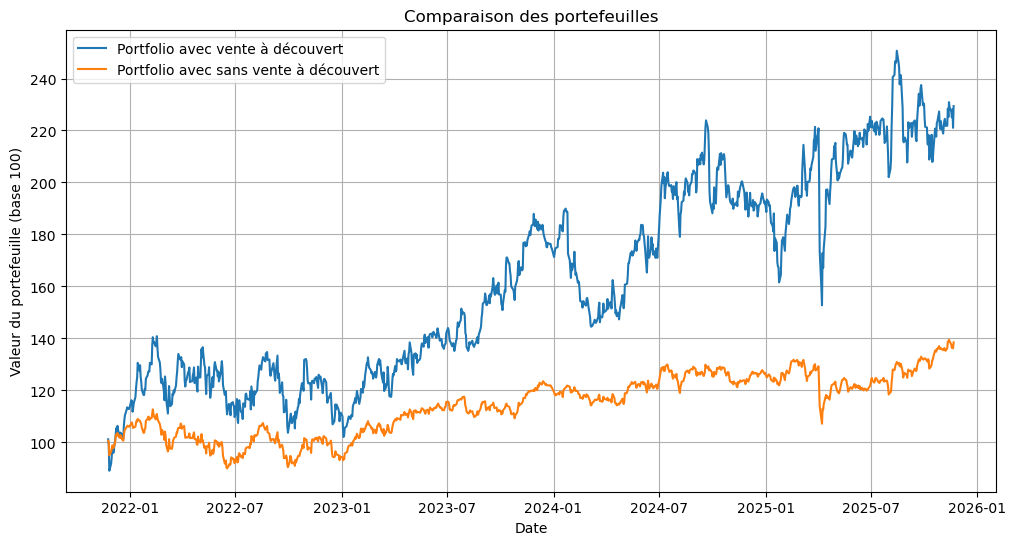

In [86]:

daily_returns = returns_df[actifs]
# Calcul du rendement quotidien du portefeuille
returns_df['Portfolio_dcvt'] = daily_returns.dot(weights_opt_dcvt)
returns_df['Portfolio_Sdcvt'] = daily_returns.dot(weights_opt_Sdcvt)

# Calcul de la valeur cumulée (base 100)
valeur_dcvt = (1 + returns_df['Portfolio_dcvt']).cumprod() * 100
valeur_Sdcvt = (1 + returns_df['Portfolio_Sdcvt']).cumprod() * 100

# Tracé des deux courbes
plt.figure(figsize=(12,6))
plt.plot(returns_df.index, valeur_dcvt, label='Portfolio avec vente à découvert')
plt.plot(returns_df.index, valeur_Sdcvt, label='Portfolio avec sans vente à découvert')
plt.xlabel('Date')
plt.ylabel('Valeur du portefeuille (base 100)')
plt.title('Comparaison des portefeuilles')
plt.legend()
plt.grid(True)
plt.show()


In [93]:
import numpy as np

def monte_carlo_var_cvar_multi_conf(returns, weights, horizon=1, confidence_levels=[0.05, 0.01], n_simulations=100000):
    """
    Calcule la VaR et la CVaR d'un portefeuille par simulation Monte Carlo
    pour plusieurs niveaux de confiance.

    Parameters
    ----------
    returns : DataFrame ou array
        Rendements quotidiens des actifs (colonnes = actifs)
    weights : array ou Series
        Poids du portefeuille
    horizon : int
        Nombre de jours pour l'horizon (1, 10, 252, etc.)
    confidence_levels : list
        Liste des niveaux de confiance (ex: [0.05, 0.01] pour 95% et 99%)
    n_simulations : int
        Nombre de tirages Monte Carlo

    Returns
    -------
    results : dict
        Dictionnaire contenant VaR et CVaR pour chaque niveau de confiance
    """
    port_rend = returns.dot(weights).values

    # Simulation Monte Carlo multi-journée
    simulated_horizon_returns = np.array([
        np.prod(1 + np.random.choice(port_rend, size=horizon, replace=True)) - 1
        for _ in range(n_simulations)
    ])

    results = {}
    for cl in confidence_levels:
        VaR = -np.percentile(simulated_horizon_returns, cl*100)
        CVaR = -simulated_horizon_returns[simulated_horizon_returns <= -VaR].mean()
        results[f"VaR_{int((1-cl)*100)}%"] = VaR
        results[f"CVaR_{int((1-cl)*100)}%"] = CVaR

    return results

# Exemple d'utilisation
results_1j = monte_carlo_var_cvar_multi_conf(daily_returns, weights_opt_dcvt, horizon=1, confidence_levels=[0.05, 0.01])
results_10j = monte_carlo_var_cvar_multi_conf(daily_returns, weights_opt_dcvt, horizon=10, confidence_levels=[0.05, 0.01])
results_1an = monte_carlo_var_cvar_multi_conf(daily_returns, weights_opt_dcvt, horizon=252, confidence_levels=[0.05, 0.01])


# Créer un DataFrame pour afficher proprement
def display_var_cvar(results_dict, horizon_label):
    VarEtCVar = pd.DataFrame(results_dict, index=[horizon_label]).T
    VarEtCVar.columns = [horizon_label]
    VarEtCVar[horizon_label] = VarEtCVar[horizon_label].round(4)
    return VarEtCVar

# Affichage joli
VarEtCVar_1j = display_var_cvar(results_1j, '1 jour')
VarEtCVar_10j = display_var_cvar(results_10j, '10 jours')
VarEtCVar_1an = display_var_cvar(results_1an, '1 an')

print("=== VaR et CVaR Monte Carlo ===\n")
print("\n",VarEtCVar_1j)
print("\n", VarEtCVar_10j)
print("\n", VarEtCVar_1an)



=== VaR et CVaR Monte Carlo ===


           1 jour
VaR_95%   0.0375
CVaR_95%  0.0529
VaR_99%   0.0582
CVaR_99%  0.0804

           10 jours
VaR_95%     0.1117
CVaR_95%    0.1439
VaR_99%     0.1646
CVaR_99%    0.1902

             1 an
VaR_95%   0.3488
CVaR_95%  0.4407
VaR_99%   0.4984
CVaR_99%  0.5609


## Les Blocs de codes qui suivent sont juste des tests

In [ ]:
# Simulation Monte Carlo des Rendements du portefeuille sans possibilité de découvert
num_scenarios = 80000
port_mean = np.dot(weights_opt_Sdcvt, mu)
port_std = np.sqrt(np.dot(weights_opt_Sdcvt.T, np.dot(cov, weights_opt_Sdcvt)))

simulated_returns = np.random.normal(port_mean/trading_days, port_std/np.sqrt(trading_days), (trading_days, num_scenarios))
portfolio_cum_returns = np.exp(np.cumsum(simulated_returns, axis=0)) - 1

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


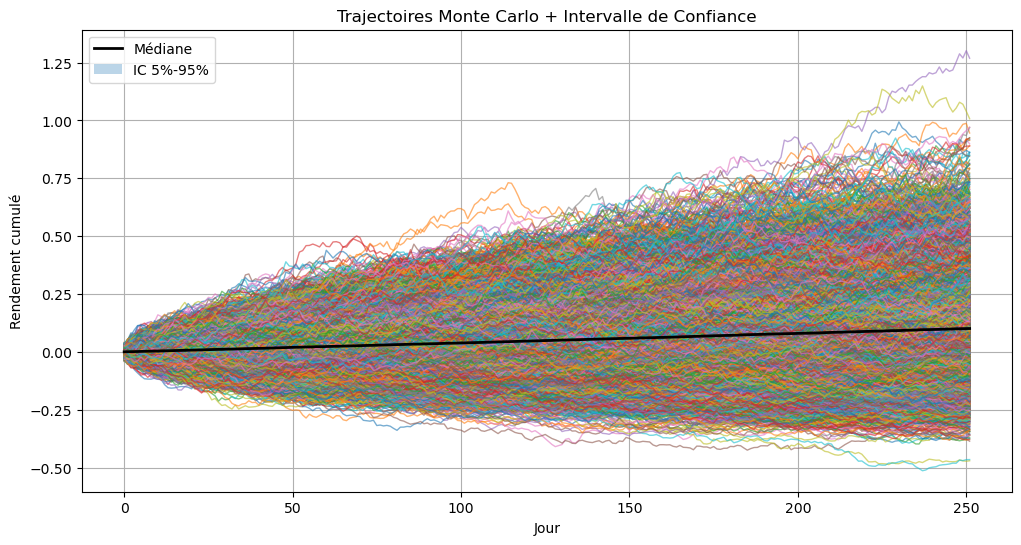

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Calcul des rendements cumulés
# --------------------------------------------------
portfolio_cum_returns = np.exp(np.cumsum(simulated_returns, axis=0)) - 1

# --------------------------------------------------
# 2. Calcul de l’intervalle de confiance
# --------------------------------------------------
median_curve = np.percentile(portfolio_cum_returns, 50, axis=1)
lower_bound = np.percentile(portfolio_cum_returns, 5, axis=1)
upper_bound = np.percentile(portfolio_cum_returns, 95, axis=1)

# --------------------------------------------------
# 3. Visualisation dans UN SEUL GRAPH
# --------------------------------------------------
plt.figure(figsize=(12,6))

# 🔹 Trajectoires simulées (on affiche 5 scénarios)
for i in range(10000):
    plt.plot(portfolio_cum_returns[:, i], alpha=0.6, linewidth=1)

# 🔹 Courbe médiane
plt.plot(median_curve, color='black', linewidth=2, label="Médiane")

# 🔹 Intervalle de confiance
plt.fill_between(range(len(median_curve)),
                 lower_bound, upper_bound,
                 alpha=0.3, label="IC 5%-95%")

plt.title("Trajectoires Monte Carlo + Intervalle de Confiance")
plt.xlabel("Jour")
plt.ylabel("Rendement cumulé")
plt.grid(True)
plt.legend()
plt.show()


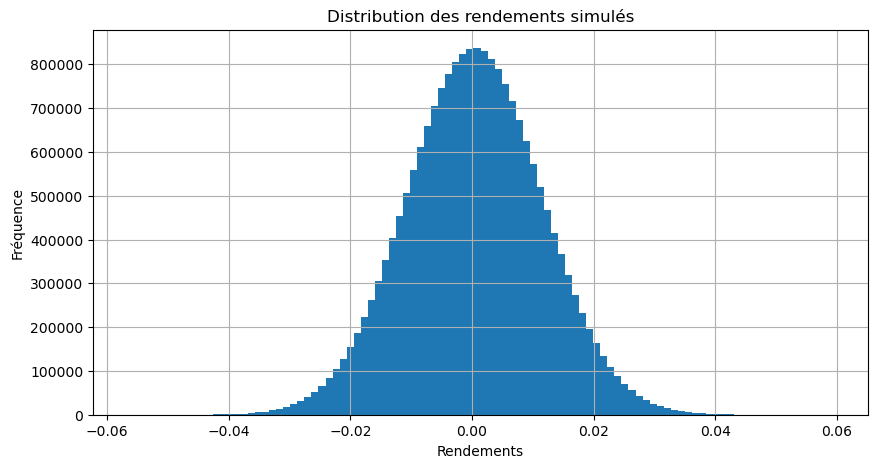

In [ ]:
# 2. Histogramme de la distribution des rendements simulés
# --------------------------------------------

plt.figure(figsize=(10,5))
plt.hist(simulated_returns.flatten(), bins=100)
plt.title("Distribution des rendements simulés")
plt.xlabel("Rendements")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


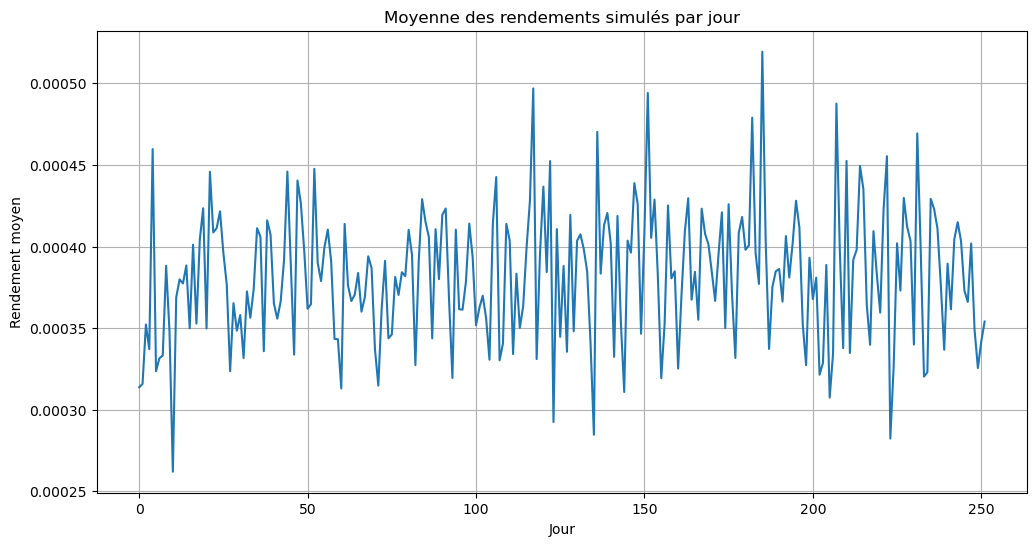

In [ ]:

# 3. Moyenne des rendements simulés par jour
# --------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(simulated_returns.mean(axis=1))
plt.title("Moyenne des rendements simulés par jour")
plt.xlabel("Jour")
plt.ylabel("Rendement moyen")
plt.grid(True)
plt.show()

# --------------------------------------------



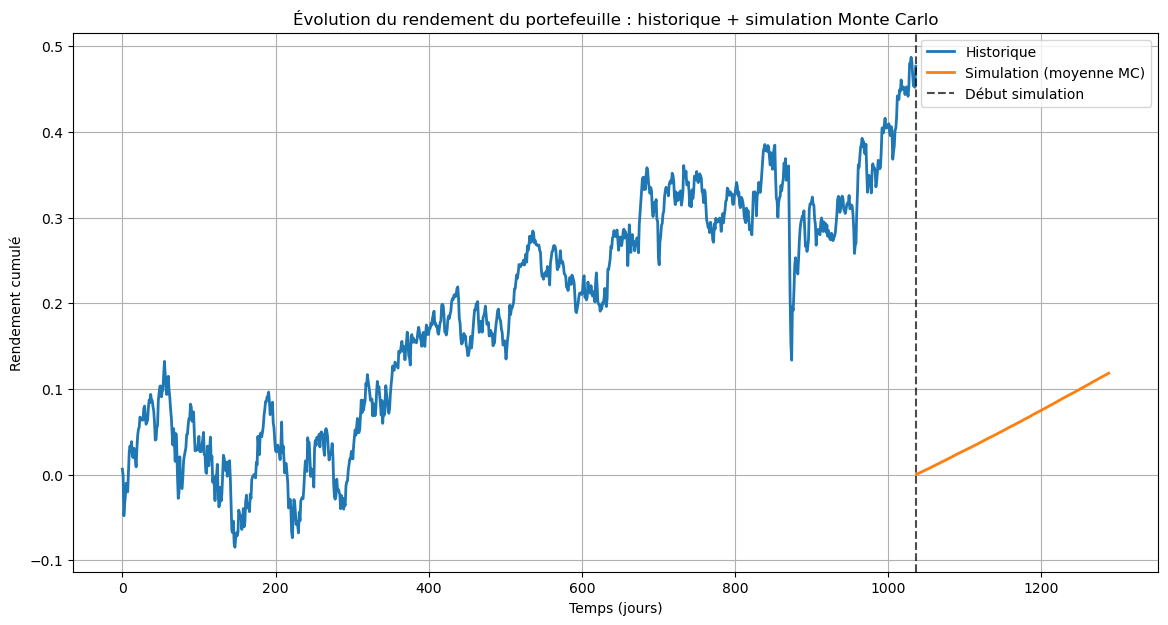

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. Calcul du rendement cumulé historique du portefeuille
# --------------------------------------------------------------
# Rendements historiques des actifs
returns_df = np.log(portfolio_df[actifs] / portfolio_df[actifs].shift(1)).dropna()

# Rendements historiques du portefeuille (pondérés)
historical_portfolio_returns = returns_df.dot(weights_opt)

# Rendements cumulés historiques
historical_cum_returns = np.exp(np.cumsum(historical_portfolio_returns)) - 1

# --------------------------------------------------------------
# 2. Calcul de la moyenne des rendements simulés (future)
# --------------------------------------------------------------
# trajectoires cumulées simulées déjà calculées :
# portfolio_cum_returns = np.exp(np.cumsum(simulated_returns, axis=0)) - 1

mean_simulated_curve = portfolio_cum_returns.mean(axis=1)

# --------------------------------------------------------------
# 3. Construction d'un axe temps combiné
# --------------------------------------------------------------
n_hist = len(historical_cum_returns)
n_sim = len(mean_simulated_curve)

# Index du temps combiné
combined_index = np.arange(n_hist + n_sim)

# --------------------------------------------------------------
# 4. Affichage sur un même graphique
# --------------------------------------------------------------
plt.figure(figsize=(14,7))

# Courbe historique
plt.plot(combined_index[:n_hist], historical_cum_returns, label="Historique", linewidth=2)

# Courbe simulation (moyenne)
plt.plot(combined_index[n_hist:], 
         mean_simulated_curve, 
         label="Simulation (moyenne MC)", 
         linewidth=2)

# Ligne verticale pour marquer la transition historique → simulation
plt.axvline(x=n_hist, color='black', linestyle='--', alpha=0.7, label="Début simulation")

plt.title("Évolution du rendement du portefeuille : historique + simulation Monte Carlo")
plt.xlabel("Temps (jours)")
plt.ylabel("Rendement cumulé")
plt.grid(True)
plt.legend()
plt.show()


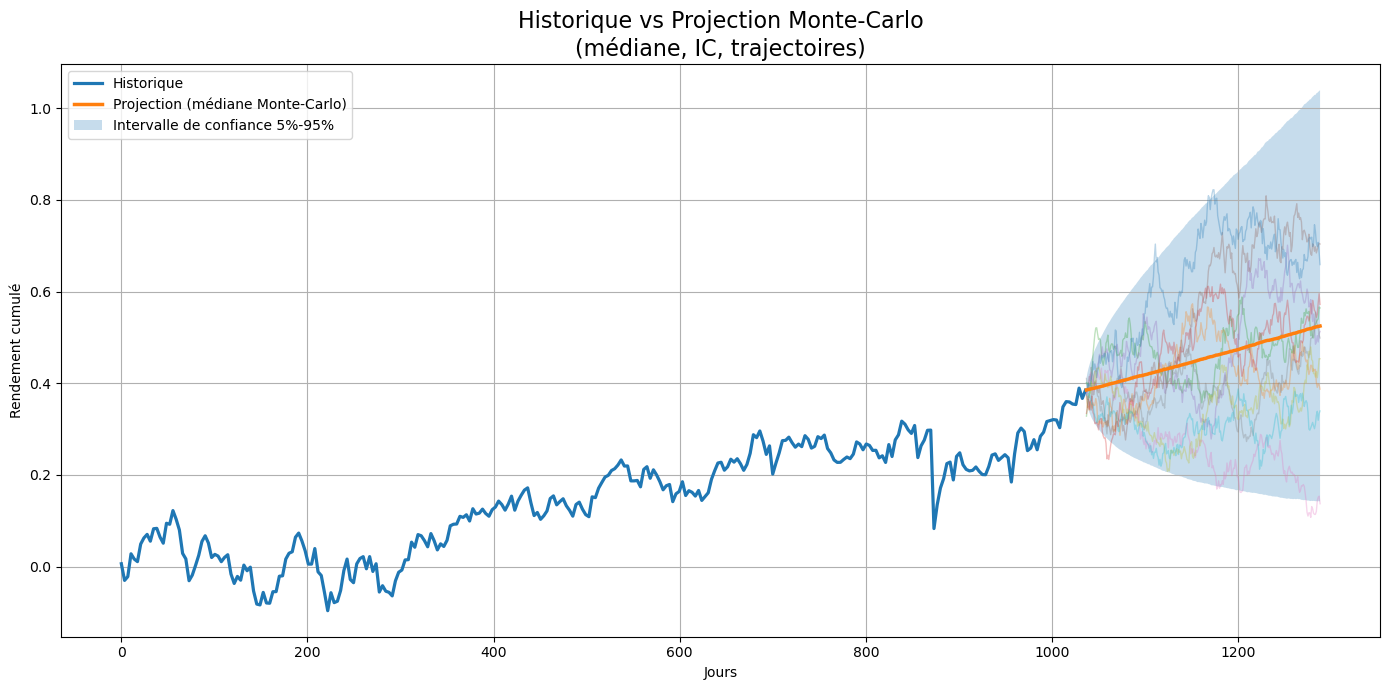

In [ ]:
from scipy.interpolate import make_interp_spline

# -----------------------------------------------------------
# 1. Rendement cumulé historique (à partir de ton dataframe)
# -----------------------------------------------------------
portfolio_returns = returns_df.dot(weights_opt)
# Rendement cumulé du portefeuille
cum_returns_hist = (1 + portfolio_returns).cumprod() - 1

# -----------------------------------------------------------
# 2. Monte-Carlo déjà calculé
# -----------------------------------------------------------

# simulated_returns : matrice [jours_simul × scénarios]
# portfolio_cum_returns : cumul Monte-Carlo déjà calculé
portfolio_cum_returns = np.exp(np.cumsum(simulated_returns, axis=0)) - 1

# -----------------------------------------------------------
# 3. Statistiques Monte-Carlo
# -----------------------------------------------------------

median_curve = np.percentile(portfolio_cum_returns, 50, axis=1)
lower_bound = np.percentile(portfolio_cum_returns, 5, axis=1)
upper_bound = np.percentile(portfolio_cum_returns, 95, axis=1)

# Pour une belle jonction entre la période historique et les simulations
last_hist = cum_returns_hist.iloc[-1]

median_shifted = (1 + median_curve) * (1 + last_hist) - 1
lower_shifted  = (1 + lower_bound) * (1 + last_hist) - 1
upper_shifted  = (1 + upper_bound) * (1 + last_hist) - 1

# -----------------------------------------------------------
# 4. Interpolation lissée pour la jonction
# -----------------------------------------------------------

smooth_x = np.linspace(0, len(cum_returns_hist)-1, 300)
spl = make_interp_spline(np.arange(len(cum_returns_hist)), cum_returns_hist.values, k=3)
smooth_hist = spl(smooth_x)

# -----------------------------------------------------------
# 5. FIGURE FINALE
# -----------------------------------------------------------

plt.figure(figsize=(14,7))

# -- Historique lissé
plt.plot(smooth_x, smooth_hist, label="Historique", linewidth=2.3)

# -- Quelques trajectoires simulées
for i in range(10):
    traj = portfolio_cum_returns[:, i]
    traj_shifted = (1 + traj) * (1 + last_hist) - 1
    plt.plot(
        range(len(cum_returns_hist), len(cum_returns_hist)+len(traj_shifted)),
        traj_shifted,
        alpha=0.3,
        linewidth=1
    )

# -- Médiane
plt.plot(
    range(len(cum_returns_hist), len(cum_returns_hist)+len(median_shifted)),
    median_shifted,
    linewidth=2.5,
    label="Projection (médiane Monte-Carlo)"
)

# -- Intervalle de confiance
plt.fill_between(
    range(len(cum_returns_hist), len(cum_returns_hist)+len(median_shifted)),
    lower_shifted,
    upper_shifted,
    alpha=0.25,
    label="Intervalle de confiance 5%-95%"
)

# -----------------------------------------------------------
# Mise en forme
# -----------------------------------------------------------

plt.title("Historique vs Projection Monte-Carlo\n(médiane, IC, trajectoires)", fontsize=16)
plt.xlabel("Jours")
plt.ylabel("Rendement cumulé")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:


# Calcul VaR et CVaR
confidence_levels = [0.95, 0.99]
for cl in confidence_levels:
    var = np.percentile(portfolio_cum_returns[-1,:], (1-cl)*100)
    cvar = portfolio_cum_returns[-1,portfolio_cum_returns[-1,:] <= var].mean()
    print(f"VaR {int(cl*100)}%: {var:.4f}")
    print(f"CVaR {int(cl*100)}%: {cvar:.4f}")


VaR 95%: -0.1751
CVaR 95%: -0.2333
VaR 99%: -0.2706
CVaR 99%: -0.3122
